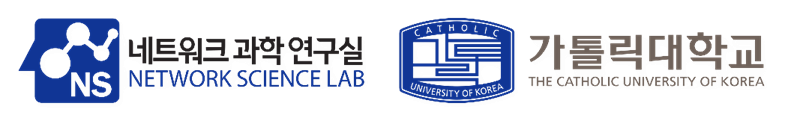

# 📊 Introduction to Graph Neural Networks
This notebook will focus on Centrality Measurements in Graphs.

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W1/Sample_Code_1.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## 📋 Table of Contents

| # | Centrality Measure | Key Idea |
|---|---|---|
| 1 | **Degree** | Number of direct connections |
| 2 | **Betweenness** | Frequency on shortest paths |
| 3 | **Closeness** | Average distance to all others |
| 4 | **Eigenvector** | Importance via important neighbors |
| 5 | **Katz** | Long-range influence with decay |
| 6 | **PageRank** | Recursive importance from links |

We use **Zachary's Karate Club** — a classic social network of 34 members — as our benchmark graph.

## ⚙️ Setup & Imports

In [1]:
import math
from collections import deque

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 🎨 Plotting configuration
plt.rcParams.update({
    "figure.figsize": (18, 15),
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 10,
})

## 🏛️ Zachary's Karate Club Graph

A social network of **34 members** of a university karate club (Zachary, 1977).  
Edges represent friendships observed outside the club.  
The network famously split into two factions — making it a classic benchmark for community detection and centrality analysis.

In [2]:
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)

print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')

Nodes: 34
Edges: 78


---
## 1️⃣ Degree Centrality

Measures a node's importance by the **fraction of nodes it is connected to**.

$$C_D(v) = \frac{\deg(v)}{n - 1}$$

- Simple and fast to compute
- Captures **local** connectivity
- High degree → hub node

In [3]:
def degree_centrality(G):
    """Compute degree centrality for each node."""
    n = G.number_of_nodes()
    if n <= 1:
        return {u: 0.0 for u in G.nodes()}
    return {u: len(list(G.neighbors(u))) / (n - 1) for u in G.nodes()}

---
## 2️⃣ Betweenness Centrality

Measures how often a node appears on **shortest paths** between other pairs.

$$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

where $\sigma_{st}$ = total shortest paths from $s$ to $t$, and $\sigma_{st}(v)$ = those passing through $v$.

- Identifies **bridge** nodes and gatekeepers
- Uses Brandes' algorithm (BFS + back-propagation)

In [4]:
def betweenness_centrality(G):
    """Brandes' algorithm for betweenness centrality."""
    nodes = list(G.nodes())
    n = len(nodes)
    bet = {u: 0.0 for u in nodes}

    for s in nodes:
        # BFS phase
        stack = []
        pred = {v: [] for v in nodes}
        sigma = {v: 0.0 for v in nodes}
        dist = {v: -1 for v in nodes}
        sigma[s] = 1.0
        dist[s] = 0
        queue = deque([s])

        while queue:
            v = queue.popleft()
            stack.append(v)
            for w in G.neighbors(v):
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1
                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)

        # Back-propagation phase
        delta = {v: 0.0 for v in nodes}
        while stack:
            w = stack.pop()
            for v in pred[w]:
                delta[v] += (sigma[v] / sigma[w]) * (1.0 + delta[w])
            if w != s:
                bet[w] += delta[w]

    # Normalization
    if G.is_directed():
        denom = (n - 1) * (n - 2)
    else:
        denom = (n - 1) * (n - 2) / 2.0

    return {u: bet[u] / denom for u in nodes}

---
## 3️⃣ Closeness Centrality

Measures how **close** a node is to all other nodes in the graph.

$$C_C(v) = \frac{n - 1}{\sum_{u \neq v} d(v, u)}$$

- High closeness → information spreads **fast** from this node
- Relies on BFS shortest-path distances

In [5]:
def bfs_distances(G, source):
    """BFS to compute shortest distances from source."""
    dist = {source: 0}
    queue = deque([source])
    while queue:
        u = queue.popleft()
        for v in G.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                queue.append(v)
    return dist


def closeness_centrality(G):
    """Compute closeness centrality for each node."""
    nodes = list(G.nodes())
    n = len(nodes)
    result = {}
    for u in nodes:
        dist = bfs_distances(G, u)
        dsum = sum(dist.values())
        result[u] = (n - 1) / dsum if dsum > 0 else 0.0
    return result

---
## 4️⃣ Eigenvector Centrality

A node is important if it is connected to **other important nodes**.

$$C_E(v) = \frac{1}{\lambda} \sum_{u \in N(v)} C_E(u)$$

Equivalently, the centrality vector $\mathbf{x}$ satisfies $A\mathbf{x} = \lambda \mathbf{x}$ (the dominant eigenvector of the adjacency matrix).

- Solved via **power iteration**
- Captures **recursive** influence

In [6]:
def eigenvector_centrality(G, max_iter=500, tol=1e-8):
    """Power iteration for eigenvector centrality."""
    nodes = list(G.nodes())
    n = len(nodes)
    if n == 0:
        return {}
    if n == 1:
        return {nodes[0]: 1.0}

    x = {u: 1.0 for u in nodes}

    for _ in range(max_iter):
        x_next = {u: 0.0 for u in nodes}
        for u in nodes:
            for v in G.neighbors(u):
                x_next[u] += x[v]

        norm = math.sqrt(sum(val ** 2 for val in x_next.values()))
        if norm == 0:
            break

        x_new = {u: x_next[u] / norm for u in nodes}
        if max(abs(x_new[u] - x[u]) for u in nodes) < tol:
            x = x_new
            break
        x = x_new

    return x

---
## 5️⃣ Katz Centrality

Extends eigenvector centrality by counting **all paths** with exponential decay.

$$C_K(v) = \sum_{k=1}^{\infty} \sum_{u} \alpha^k (A^k)_{vu} + \beta$$

- $\alpha$ controls decay (must be $< 1/\lambda_{\max}$)
- $\beta$ gives every node a baseline score
- Captures **long-range** influence

In [7]:
def katz_centrality(G, alpha=0.03, beta=1.0, max_iter=500, tol=1e-8):
    """Iterative Katz centrality computation."""
    nodes = list(G.nodes())
    n = len(nodes)
    if n == 0:
        return {}
    if n == 1:
        return {nodes[0]: beta}

    x = {u: 1.0 for u in nodes}

    for _ in range(max_iter):
        x_new = {u: beta for u in nodes}
        for u in nodes:
            for v in G.neighbors(u):
                x_new[u] += alpha * x[v]

        norm = math.sqrt(sum(val ** 2 for val in x_new.values()))
        if norm == 0:
            break

        x_new = {u: x_new[u] / norm for u in nodes}
        if max(abs(x_new[u] - x[u]) for u in nodes) < tol:
            x = x_new
            break
        x = x_new

    return x

---
## 6️⃣ PageRank

Models a **random surfer** who follows links with probability $d$ or jumps randomly.

$$PR(v) = \frac{1 - d}{n} + d \sum_{u \in \text{in}(v)} \frac{PR(u)}{\deg^{\text{out}}(u)}$$

- $d = 0.85$ (damping factor) is the standard choice
- Originally designed for web page ranking (Google)
- For undirected graphs, $\text{in}(v) = N(v)$

In [8]:
def pagerank(G, damping=0.85, max_iter=100, tol=1e-8):
    """Iterative PageRank computation."""
    nodes = list(G.nodes())
    n = len(nodes)
    if n == 0:
        return {}
    if n == 1:
        return {nodes[0]: 1.0}

    pr = {u: 1.0 / n for u in nodes}
    out_degree = {u: len(list(G.neighbors(u))) for u in nodes}

    for _ in range(max_iter):
        new_pr = {u: (1 - damping) / n for u in nodes}
        for u in nodes:
            incoming = [v for v in nodes if u in G.neighbors(v)]
            for v in incoming:
                new_pr[u] += damping * pr[v] / out_degree[v]

        diff = max(abs(new_pr[u] - pr[u]) for u in nodes)
        pr = new_pr
        if diff < tol:
            break

    return pr

---
## 🧪 Compute All Centralities

In [9]:
centrality = {
    "Degree": degree_centrality(G),
    "Betweenness": betweenness_centrality(G),
    "Closeness": closeness_centrality(G),
    "Eigenvector": eigenvector_centrality(G),
    "Katz": katz_centrality(G, alpha=0.03, beta=1.0),
    "PageRank": pagerank(G, damping=0.85),
}

---
## 🎨 Comparison Figure


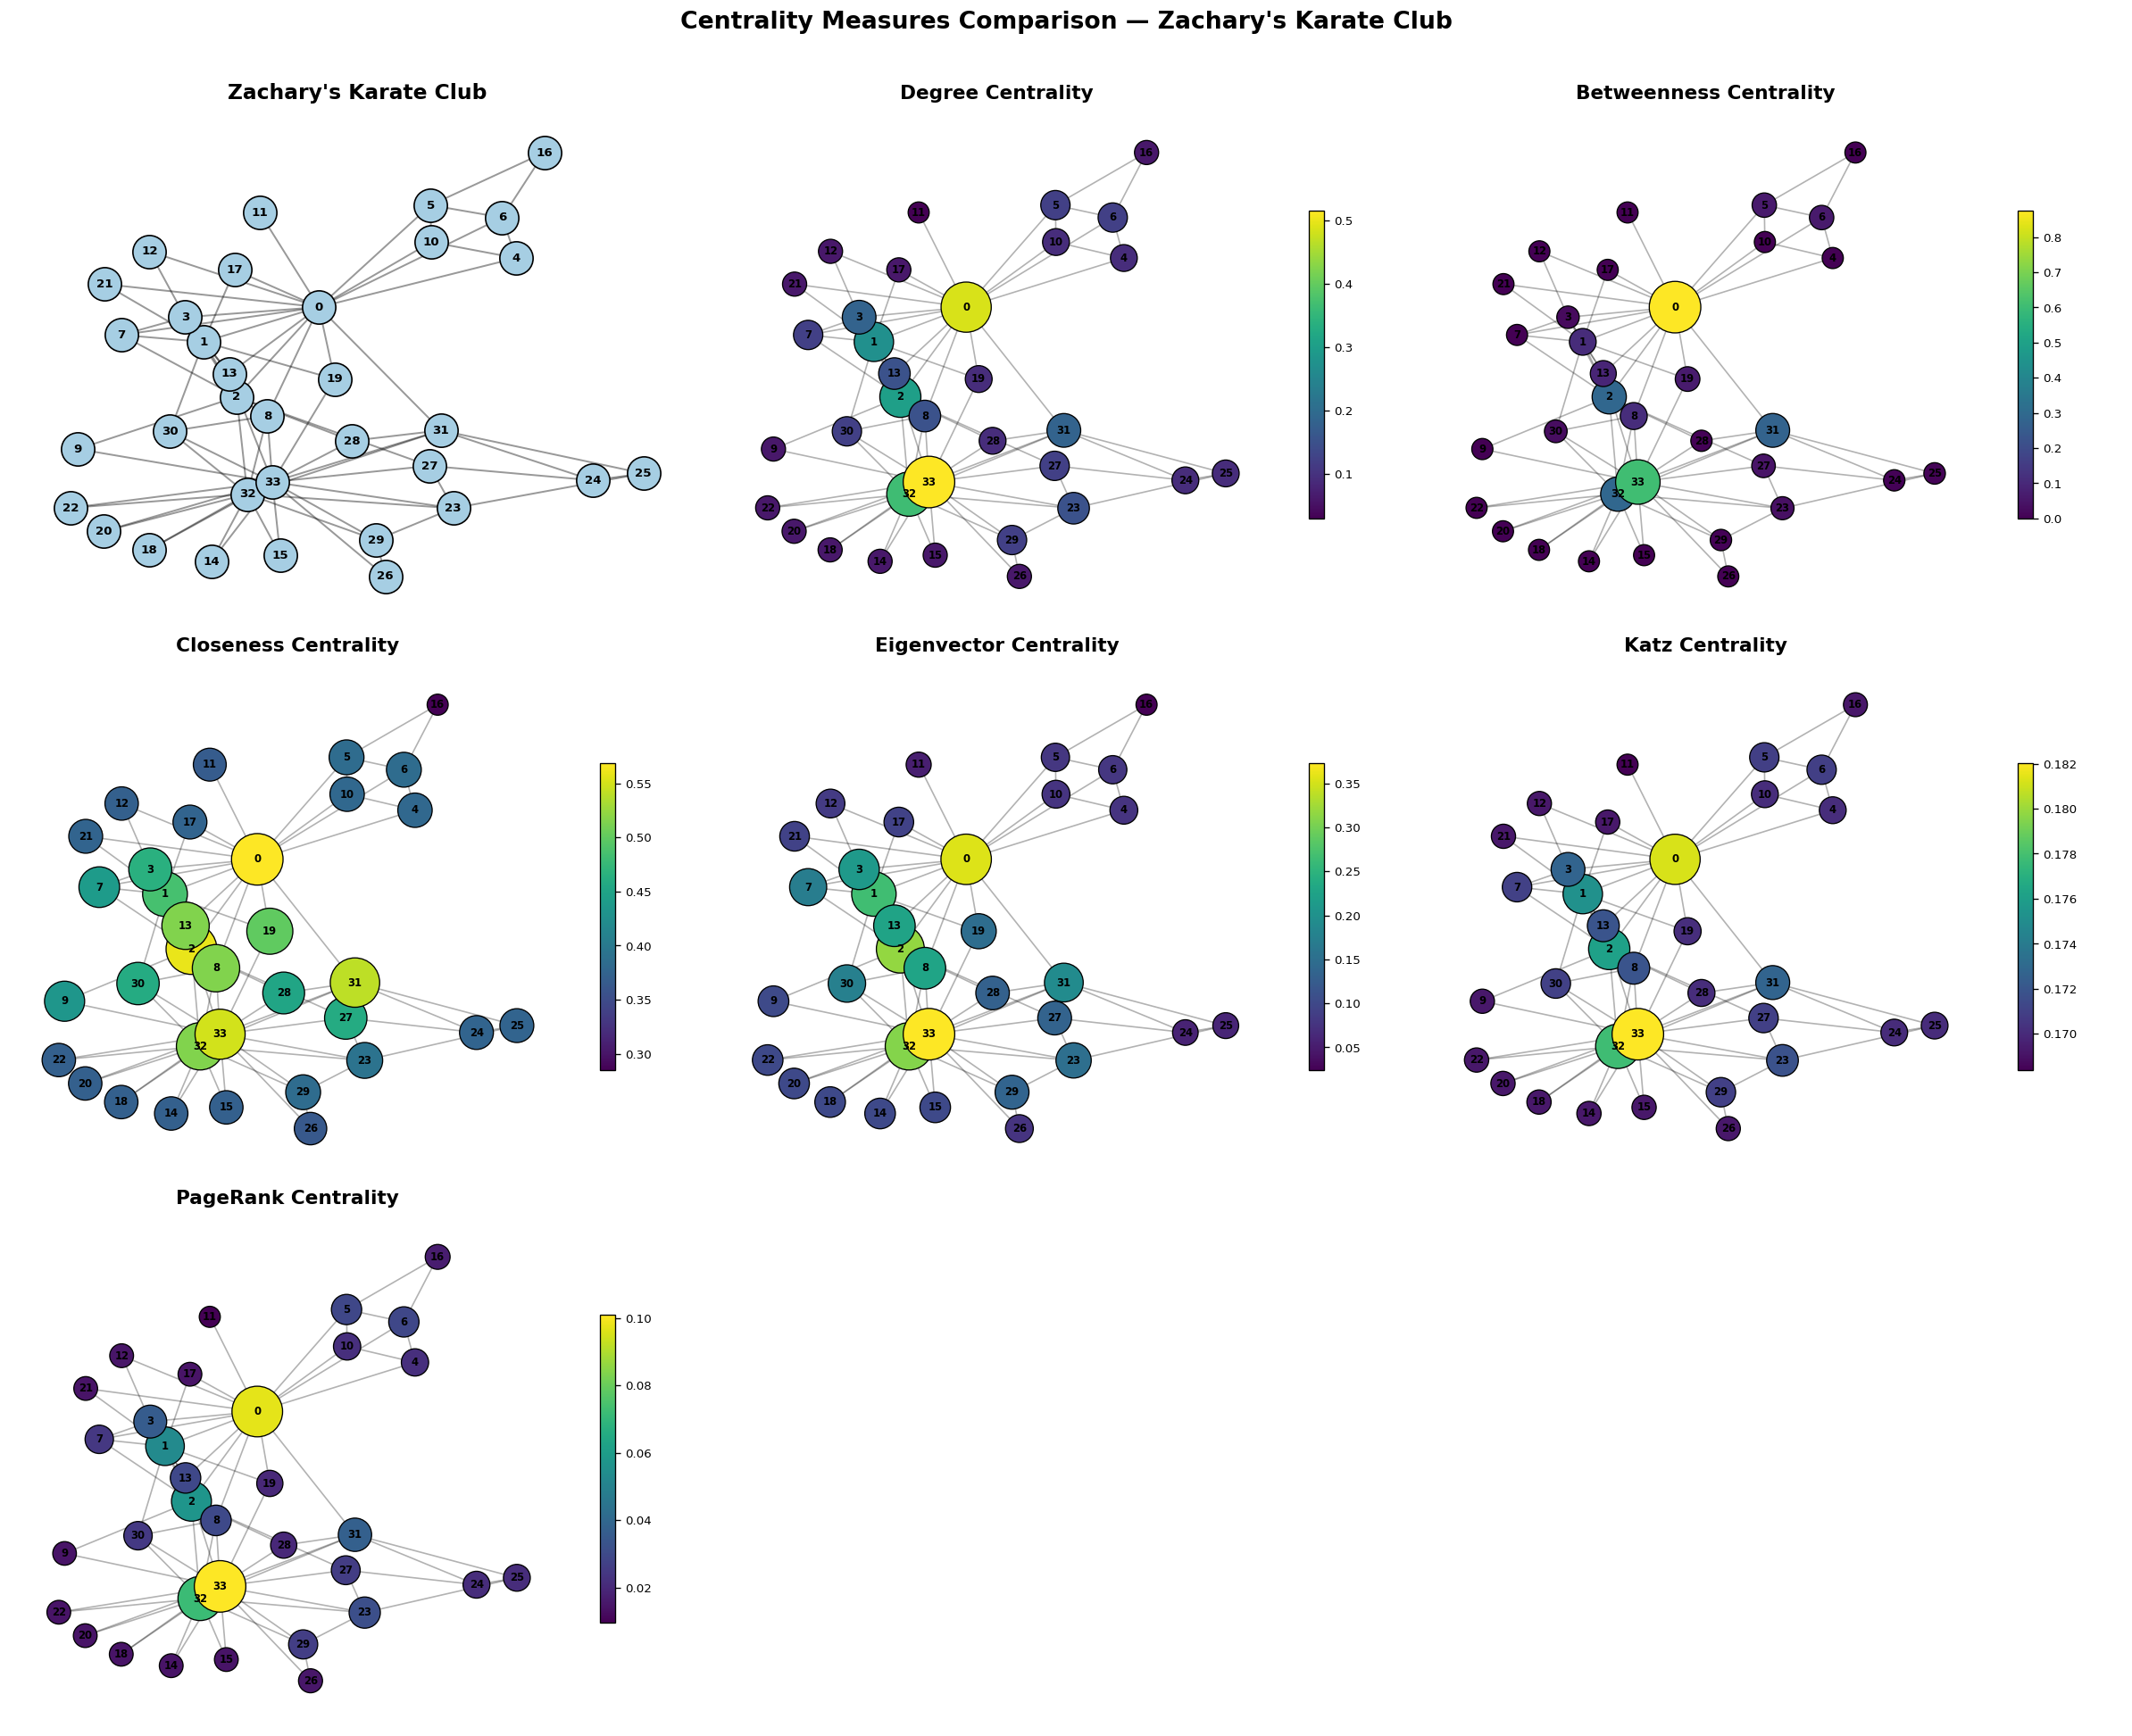

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.ravel()

# --- Panel 0: Plain Karate Club Graph ---
nx.draw_networkx_edges(G, pos, ax=axes[0], alpha=0.4, width=1.2)
nx.draw_networkx_nodes(
    G, pos, ax=axes[0], node_color="#A6CEE3",
    node_size=500, edgecolors="black", linewidths=1.0
)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=8, font_weight='bold')
axes[0].set_title("Zachary's Karate Club", fontsize=14, fontweight="bold")
axes[0].axis("off")

# --- Panels 1–6: Centrality Heatmaps ---
cmap = cm.viridis

for idx, (name, values) in enumerate(centrality.items(), start=1):
    ax = axes[idx]
    vals = np.array([values[n] for n in G.nodes()])
    vmin, vmax = vals.min(), vals.max()

    # Scale node sizes between 200 and 1200
    if vmax > vmin:
        sizes = 200 + 1000 * (vals - vmin) / (vmax - vmin)
    else:
        sizes = np.full_like(vals, 500)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=1.0)
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=vals.tolist(),
        node_size=sizes.tolist(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolors="black", linewidths=0.8
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_weight="bold")
    ax.set_title(f"{name} Centrality", fontsize=13, fontweight="bold")
    ax.axis("off")

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=20)
    cbar.ax.tick_params(labelsize=8)

# Hide unused subplots
for j in range(len(centrality) + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Centrality Measures Comparison — Zachary's Karate Club",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()